# Autoencoders — PyTorch (GPU-Accelerated)

## Model: Dense Autoencoder + Convolutional Denoising Autoencoder
- **Dataset**: CIFAR-10 — 50,000 train / 10,000 test, 3,072 features (32×32×3 RGB)
- **Task**: Reconstruct input images through bottleneck compression (self-supervised)
- **Framework showcase**: Conv Denoising AE — architecture sweep + noise level sweep on GPU

## GPU Acceleration Strategy
- All tensor ops on CUDA (encoder, decoder, loss computation)
- `nn.Module` subclass for both dense and convolutional architectures
- Adam optimizer with mini-batch training via DataLoader
- Gaussian noise injection: `torch.clamp(clean + σ * torch.randn_like(clean), 0, 1)`

## Evaluation Strategy
- **Metrics**: Reconstruction MSE/MAE, downstream KNN accuracy (K=5) on latent features
- **Visualizations**: Reconstruction grids (RGB), training loss curves, latent space t-SNE

## Pipeline
1. Load data + config
2. Simple dense autoencoder (baseline, match SK)
3. Training history + reconstruction visualization
4. Conv denoising AE — architecture sweep (showcase)
5. Dense vs best conv denoising comparison
6. Latent space + downstream classification
7. Performance benchmarks
8. Save results

In [1]:
# Step 1: Setup

"""
Imports, config, load preprocessed CIFAR-10, GPU tensors
Dense AE baseline matches SK (3072-512-128-512-3072)
Conv denoising AE uses image-shaped data (3, 32, 32)
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_training_history, plot_reconstruction_grid,
                                  plot_latent_space)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
MODEL_NAME = "Autoencoder"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SHAPE = (32, 32, 3)
N_FEATURES = 3072  # 32 * 32 * 3
N_CHANNELS = 3
BATCH_SIZE = 128
LATENT_DIM = 128  # Baseline bottleneck (matches SK)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load preprocessed CIFAR-10 — flattened for dense AE
X_train_flat, X_test_flat, y_train, y_test, metadata = load_processed_data('autoencoder')

# Image-shaped data for conv AE
X_train_img = np.load('../../data/processed/autoencoder/X_train_img.npy')
X_test_img = np.load('../../data/processed/autoencoder/X_test_img.npy')

# GPU tensors — flattened (dense AE)
X_train_t = torch.tensor(X_train_flat, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test_flat, dtype=torch.float32, device=device)

# GPU tensors — image-shaped, channel-first for Conv2d: (N, 32, 32, 3) → (N, 3, 32, 32)
X_train_img_t = torch.tensor(X_train_img, dtype=torch.float32, device=device).permute(0, 3, 1, 2)
X_test_img_t = torch.tensor(X_test_img, dtype=torch.float32, device=device).permute(0, 3, 1, 2)

y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

# DataLoaders — input IS the target (self-supervised reconstruction)
train_flat_ds = TensorDataset(X_train_t, X_train_t)
train_flat_loader = DataLoader(train_flat_ds, batch_size=BATCH_SIZE, shuffle=True)

train_img_ds = TensorDataset(X_train_img_t, X_train_img_t)
train_img_loader = DataLoader(train_img_ds, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/8] Data loaded — {FRAMEWORK} {MODEL_NAME}")
print("=" * 60)
print(f"  Device: {device} ({torch.cuda.get_device_name(0)})")
print(f"  Train flat: {X_train_t.shape} | Test flat: {X_test_t.shape}")
print(f"  Train img:  {X_train_img_t.shape} | Test img:  {X_test_img_t.shape}")
print(f"  Classes: {len(CLASS_NAMES)}")
print(f"  Batch size: {BATCH_SIZE} ({len(train_flat_loader)} batches/epoch)")
print(f"  Pixel range: [{X_train_t.min():.1f}, {X_train_t.max():.1f}]")
print(f"  GPU memory: {torch.cuda.memory_allocated() / 1e6:.1f} MB")

[1/8] Data loaded — PyTorch Autoencoder
  Device: cuda (NVIDIA GeForce RTX 4090)
  Train flat: torch.Size([50000, 3072]) | Test flat: torch.Size([10000, 3072])
  Train img:  torch.Size([50000, 3, 32, 32]) | Test img:  torch.Size([10000, 3, 32, 32])
  Classes: 10
  Batch size: 128 (391 batches/epoch)
  Pixel range: [0.0, 1.0]
  GPU memory: 1476.9 MB


In [2]:
# Step 2: Simple Dense Autoencoder

"""
Same architecture as SK: 3072 → 512 → 128 → 512 → 3072
Sigmoid output maps to [0,1] pixel space
Mini-batch training with early stopping on validation loss
"""

print("=" * 60)
print("[2/8] Simple Dense Autoencoder — Baseline")
print("=" * 60)

class DenseAutoencoder(nn.Module):
    # Symmetric dense autoencoder with configurable bottleneck.
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Output in [0,1] for pixel reconstruction
        )

    def forward(self, x):
        latent = self.encoder(x)
        recon = self.decoder(latent)
        return recon

    def encode(self, x):
        return self.encoder(x)

# Build model — matches SK's 3072-512-128-512-3072
dense_ae = DenseAutoencoder(N_FEATURES, 512, LATENT_DIM).to(device)
optimizer = optim.Adam(dense_ae.parameters())
criterion = nn.MSELoss()

# Train/val split (90/10)
n_val = int(len(X_train_t) * 0.1)
indices = torch.randperm(len(X_train_t), device=device,
                          generator=torch.Generator(device=device).manual_seed(RANDOM_STATE))
val_idx, train_idx = indices[:n_val], indices[n_val:]

X_val_flat = X_train_t[val_idx]
X_train_split = X_train_t[train_idx]

train_ds = TensorDataset(X_train_split, X_train_split)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# Training loop with early stopping
MAX_EPOCHS = 200
PATIENCE = 15
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []

with track_performance(gpu=True) as perf:
    for epoch in range(MAX_EPOCHS):
        # Train
        dense_ae.train()
        epoch_loss = 0.0
        for batch_x, batch_target in train_loader:
            optimizer.zero_grad()
            recon = dense_ae(batch_x)
            loss = criterion(recon, batch_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch_x)
        train_loss = epoch_loss / len(X_train_split)
        train_losses.append(train_loss)

        # Validate
        dense_ae.eval()
        with torch.no_grad():
            val_recon = dense_ae(X_val_flat)
            val_loss = criterion(val_recon, X_val_flat).item()
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in dense_ae.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    torch.cuda.synchronize()

# Restore best weights
dense_ae.load_state_dict(best_state)
best_epoch = len(train_losses) - PATIENCE

# Reconstruct test set
dense_ae.eval()
with torch.no_grad():
    X_test_recon_t = dense_ae(X_test_t)
X_test_recon = X_test_recon_t.cpu().numpy()

# Reconstruction metrics
baseline_mse = np.mean((X_test_flat - X_test_recon) ** 2)
baseline_mae = np.mean(np.abs(X_test_flat - X_test_recon))

n_params = sum(p.numel() for p in dense_ae.parameters())

print(f"\nArchitecture: 3072 → 512 → 128 → 512 → 3072")
print(f"Epochs: {len(train_losses)} (early stopped at best epoch {best_epoch})")
print(f"Best val loss: {best_val_loss:.6f}")
print(f"Training time: {perf['time']:.2f}s")
print(f"GPU memory: {perf['gpu_memory']:.2f} MB")
print(f"Peak CPU memory: {perf['memory']:.2f} MB")
print(f"\nReconstruction Quality (test set):")
print(f"  MSE:  {baseline_mse:.6f}")
print(f"  MAE:  {baseline_mae:.6f}")
print(f"  RMSE: {np.sqrt(baseline_mse):.6f}")
print(f"\nParameters: {n_params:,}")
print(f"\nSK baseline comparison: MSE 0.0133 (10K subset)")

[2/8] Simple Dense Autoencoder — Baseline

Architecture: 3072 → 512 → 128 → 512 → 3072
Epochs: 125 (early stopped at best epoch 110)
Best val loss: 0.009058
Training time: 117.52s
GPU memory: 2255.86 MB
Peak CPU memory: 1.92 MB

Reconstruction Quality (test set):
  MSE:  0.009055
  MAE:  0.068719
  RMSE: 0.095160

Parameters: 3,281,024

SK baseline comparison: MSE 0.0133 (10K subset)


[3/8] Visualizations


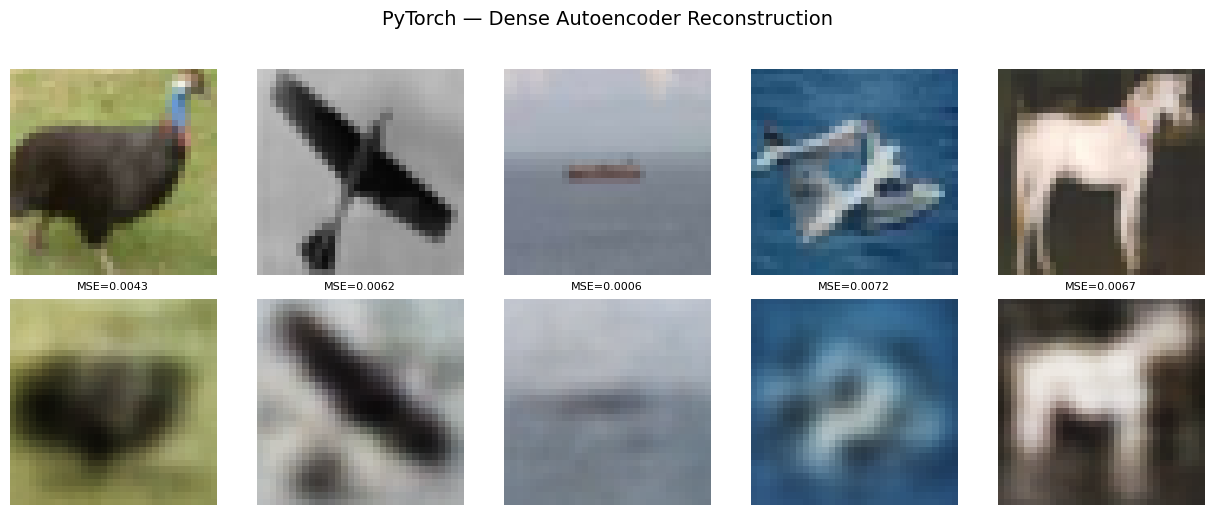

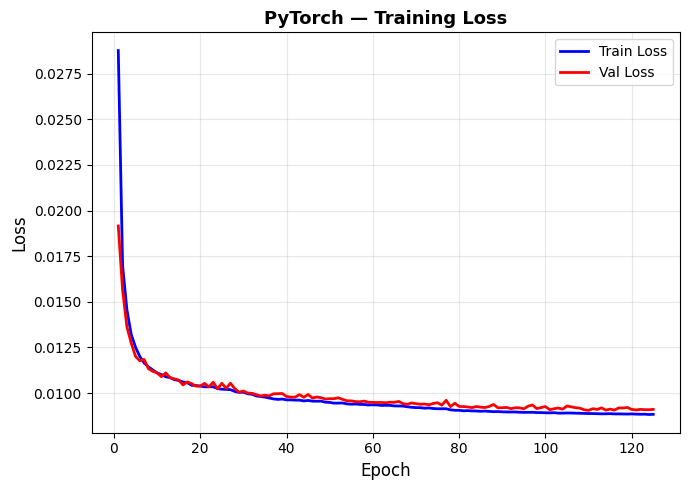


Training: 125 epochs
Final train loss: 0.008839
Best val loss:    0.009058 (epoch 110)


In [3]:
# Step 3: Visualizations

# Reconstruction grid (RGB) + training loss curve


print("=" * 60)
print("[3/8] Visualizations")
print("=" * 60)

# Reconstruction Grid
rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test_flat), 5, replace=False)

recon_dict = {128: X_test_recon[viz_idx]}
plot_reconstruction_grid(
    originals=X_test_flat[viz_idx],
    reconstructions_dict=recon_dict,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Dense Autoencoder Reconstruction',
    row_label_prefix='dim',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/reconstruction_dense.png'
)

# Training Loss Curve
history = {
    'train_loss': train_losses,
    'val_loss': val_losses
}

plot_training_history(
    history=history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_dense.png'
)

print(f"\nTraining: {len(train_losses)} epochs")
print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Best val loss:    {best_val_loss:.6f} (epoch {best_epoch})")